# Feature Engineering — Chuyển Graph Metrics thành Feature Vector cho ML

**Input:**
- `graph_analysis_output/node_metrics.csv` — centrality metrics từ bước 4
- `knowledge_graph_output/triples.csv` — toàn bộ triples từ bước 3
- `knowledge_graph_output/knowledge_graph.graphml` — graph structure

**Pipeline:**
```
node_metrics.csv  ──┐
triples.csv       ──┼──► [1] Load & Validate ──► [2] Raw Feature Matrix
graphml           ──┘                                      │
                                                           ▼
                                            [3] Feature Engineering
                                     ┌──────────────────────────────────┐
                                     │  3a. Graph structural features   │
                                     │  3b. Interaction features        │
                                     │  3c. Ratio & log transforms      │
                                     │  3d. Community-relative features │
                                     │  3e. Triple quality features     │
                                     │  3f. Entity type one-hot         │
                                     │  3g. Temporal features           │
                                     │  3h. Ego-network features        │
                                     └──────────────────────────────────┘
                                                           │
                                                           ▼
                                     [4] Feature Selection & Importance
                                                           │
                                                           ▼
                                     [5] Scaling & Normalization
                                                           │
                                                           ▼
                                     [6] Label Engineering
                                                           │
                                                           ▼
                                     [7] Train/Val/Test Split
                                                           │
                                                           ▼
                                          [8] Export + Quality Report
```

**Output files:**

| File | Dùng cho |
|------|----------|
| `node_features.csv` | **Bước 6** — ML training (full feature matrix) |
| `node_features_scaled.csv` | **Bước 6** — ML training (đã scale) |
| `X_train/val/test.csv` | **Bước 6** — train/val/test splits |
| `y_train/val/test.csv` | **Bước 6** — labels |
| `feature_names.json` | Danh sách tên features (theo thứ tự) |
| `feature_importance.csv` | Variance-based importance ranking |
| `scaler_params.json` | Mean/std để inverse-transform sau này |
| `label_encoder.json` | Label mapping (LOW/MEDIUM/HIGH → 0/1/2) |
| `feature_report.png` | Visualization tổng hợp |

## 0. Cài đặt thư viện

In [1]:
import subprocess, sys

pkgs = [
    'pandas>=2.0',
    'numpy>=1.24',
    'scikit-learn>=1.3',
    'networkx>=3.2',
    'matplotlib>=3.7',
    'seaborn>=0.12',
    'scipy>=1.11',
    'lxml',
    'tqdm',
]
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q'] + pkgs, check=True)
print('Done.')

Done.


## 1. Import & Config

In [2]:
import json
import warnings
from pathlib import Path
from typing import Dict, List, Tuple
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.0)
plt.rcParams['figure.dpi'] = 120

# ── Config ──────────────────────────────────────────────────
CFG = {
    # Input — output từ bước 3 và bước 4
    'node_metrics_csv' : 'data/graph_metrics/node_metrics.csv',
    'triples_csv'      : 'data/triples.csv',
    'graphml_path'     : 'knowledge_graph_output/knowledge_graph.graphml',

    # Label engineering
    # Dùng influence_score từ bước 4 làm proxy label (mức độ ảnh hưởng doanh nghiệp)
    # Có thể đổi thành: pagerank, betweenness, total_degree
    'label_source'     : 'influence_score',
    'label_bins'       : [0.0, 0.25, 0.60, 1.0],   # LOW / MEDIUM / HIGH
    'label_names'      : ['LOW', 'MEDIUM', 'HIGH'],

    # Feature selection
    'variance_threshold' : 0.001,  # loại features gần như không đổi
    'corr_threshold'     : 0.95,   # loại features tương quan quá cao
    'top_k_features'     : 40,     # giữ top-K features quan trọng nhất

    # Train/val/test split
    'val_size'   : 0.15,
    'test_size'  : 0.15,
    'random_seed': 42,

    # Scaling method: 'standard' | 'minmax' | 'robust'
    # robust: tốt hơn khi có nhiều outlier (thường gặp trong graph metrics)
    'scaler_type': 'robust',

    # Output
    'output_dir' : 'feature_engineering_output',
}

OUT = Path(CFG['output_dir'])
OUT.mkdir(exist_ok=True)

print('Config loaded:')
for k, v in CFG.items():
    print(f'  {k:25s}: {v}')

Config loaded:
  node_metrics_csv         : data/graph_metrics/node_metrics.csv
  triples_csv              : data/triples.csv
  graphml_path             : knowledge_graph_output/knowledge_graph.graphml
  label_source             : influence_score
  label_bins               : [0.0, 0.25, 0.6, 1.0]
  label_names              : ['LOW', 'MEDIUM', 'HIGH']
  variance_threshold       : 0.001
  corr_threshold           : 0.95
  top_k_features           : 40
  val_size                 : 0.15
  test_size                : 0.15
  random_seed              : 42
  scaler_type              : robust
  output_dir               : feature_engineering_output


c:\Users\OS\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load Data

In [3]:
# ── Load node metrics (từ bước 4) ───────────────────────────
print(f'Loading node metrics: {CFG["node_metrics_csv"]} ...')
df_metrics = pd.read_csv(CFG['node_metrics_csv'])
print(f'  Shape : {df_metrics.shape}')
print(f'  Columns: {list(df_metrics.columns)}')

# ── Load triples (từ bước 3) ─────────────────────────────────
print(f'\nLoading triples: {CFG["triples_csv"]} ...')
df_triples = pd.read_csv(CFG['triples_csv'])
print(f'  Shape : {df_triples.shape}')
print(f'  Columns: {list(df_triples.columns)}')
print(f'  Relation types: {df_triples["relation"].nunique()}')
print(f'  Relation distribution:')
print(df_triples['relation'].value_counts().to_string())

# ── Load graph ───────────────────────────────────────────────
print(f'\nLoading graph: {CFG["graphml_path"]} ...')
G = nx.read_graphml(CFG['graphml_path'])
print(f'  Nodes : {G.number_of_nodes():,}')
print(f'  Edges : {G.number_of_edges():,}')

# ── Validate alignment ───────────────────────────────────────
metrics_nodes = set(df_metrics['node'].astype(str))
graph_nodes   = set(G.nodes())
print(f'\nNode alignment check:')
print(f'  node_metrics.csv : {len(metrics_nodes):,} nodes')
print(f'  graph             : {len(graph_nodes):,} nodes')
overlap = metrics_nodes & graph_nodes
print(f'  Overlap           : {len(overlap):,} nodes ({len(overlap)/len(metrics_nodes)*100:.1f}%)')

# Ensure string dtype for node column
df_metrics['node'] = df_metrics['node'].astype(str)
print(f'\nMissing values in node_metrics:')
print(df_metrics.isnull().sum()[df_metrics.isnull().sum() > 0].to_string() or '  None')

Loading node metrics: data/graph_metrics/node_metrics.csv ...
  Shape : (7288, 7)
  Columns: ['node', 'entity_type', 'in_degree', 'out_degree', 'degree', 'betweenness', 'pagerank']

Loading triples: data/triples.csv ...
  Shape : (6298, 10)
  Columns: ['subject', 'subject_type', 'relation', 'object', 'object_type', 'confidence', 'frequency', 'weight', 'source_id', 'source_text']
  Relation types: 12
  Relation distribution:
relation
LÃNH_ĐẠO           1835
CÓ_GIÁ_TRỊ         1528
TĂNG_TRƯỞNG        1361
HỢP_TÁC            1002
THUỘC_NGÀNH         270
ĐẶT_TẠI              82
ĐẦU_TƯ               70
LIÊN_QUAN            69
SẢN_XUẤT             38
TỔ_CHỨC_SỰ_KIỆN      27
XẢY_RA_TẠI           12
THAM_GIA              4

Loading graph: knowledge_graph_output/knowledge_graph.graphml ...
  Nodes : 7,288
  Edges : 6,226

Node alignment check:
  node_metrics.csv : 7,288 nodes
  graph             : 7,288 nodes
  Overlap           : 7,288 nodes (100.0%)

Missing values in node_metrics:
Series([],

## 3. Feature Engineering

### 3a. Graph Structural Features

Giữ nguyên các raw metrics từ bước 4 làm baseline features.

In [4]:
df = df_metrics.copy()

# Các cột graph metrics cốt lõi từ bước 4
GRAPH_COLS = [
    'in_degree', 'out_degree', 'total_degree',
    'in_strength', 'out_strength', 'total_strength',
    'betweenness', 'pagerank', 'pagerank_unweighted',
    'hub_score', 'authority_score',
    'avg_edge_confidence', 'max_edge_confidence',
    'avg_edge_frequency', 'total_edge_frequency',
    'relation_diversity',
]

# Kiểm tra cột nào thực sự tồn tại
existing_graph_cols = [c for c in GRAPH_COLS if c in df.columns]
missing_graph_cols  = [c for c in GRAPH_COLS if c not in df.columns]

print(f'Graph features available : {len(existing_graph_cols)}')
print(f'Graph features missing   : {missing_graph_cols}')

# Fill missing với 0
for col in missing_graph_cols:
    df[col] = 0.0

# Tất cả numeric: fill NaN với median
for col in existing_graph_cols:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f'  Filled NaN in {col} with median={median_val:.4f}')

print(f'\nRaw graph feature stats:')
print(df[existing_graph_cols].describe().round(4).to_string())

Graph features available : 4
Graph features missing   : ['total_degree', 'in_strength', 'out_strength', 'total_strength', 'pagerank_unweighted', 'hub_score', 'authority_score', 'avg_edge_confidence', 'max_edge_confidence', 'avg_edge_frequency', 'total_edge_frequency', 'relation_diversity']

Raw graph feature stats:
       in_degree  out_degree  betweenness   pagerank
count  7288.0000   7288.0000    7288.0000  7288.0000
mean      0.8543      0.8543       0.0000     0.0001
std       1.6719      2.2984       0.0001     0.0001
min       0.0000      0.0000       0.0000     0.0001
25%       0.0000      0.0000       0.0000     0.0001
50%       1.0000      1.0000       0.0000     0.0001
75%       1.0000      1.0000       0.0000     0.0001
max      53.0000     93.0000       0.0019     0.0033


### 3b. Interaction Features

Kết hợp các metrics để tạo features mới có ý nghĩa:

In [5]:
# ── PageRank × Degree: entity vừa được nhiều bên trỏ vào, vừa có nhiều kết nối
df['pr_x_degree']        = df['pagerank'] * df['total_degree']

# ── Betweenness × Diversity: broker có nhiều loại quan hệ khác nhau
df['bw_x_diversity']     = df['betweenness'] * df['relation_diversity']

# ── Hub × Authority: entity vừa là hub vừa là authority (rare, high value)
df['hub_x_authority']    = df['hub_score'] * df['authority_score']

# ── PageRank × Confidence: authority được verify bởi high-confidence edges
df['pr_x_confidence']    = df['pagerank'] * df['avg_edge_confidence']

# ── Strength × Confidence: tổng trọng số edge × quality trung bình
df['strength_x_conf']    = df['total_strength'] * df['avg_edge_confidence']

# ── Betweenness × PageRank: entity quan trọng theo cả 2 tiêu chí
df['bw_x_pr']            = df['betweenness'] * df['pagerank']

INTERACTION_COLS = [
    'pr_x_degree', 'bw_x_diversity', 'hub_x_authority',
    'pr_x_confidence', 'strength_x_conf', 'bw_x_pr',
]
print(f'Interaction features: {INTERACTION_COLS}')
print(df[INTERACTION_COLS].describe().round(6).to_string())

Interaction features: ['pr_x_degree', 'bw_x_diversity', 'hub_x_authority', 'pr_x_confidence', 'strength_x_conf', 'bw_x_pr']
       pr_x_degree  bw_x_diversity  hub_x_authority  pr_x_confidence  strength_x_conf      bw_x_pr
count       7288.0          7288.0           7288.0           7288.0           7288.0  7288.000000
mean           0.0             0.0              0.0              0.0              0.0     0.000000
std            0.0             0.0              0.0              0.0              0.0     0.000000
min            0.0             0.0              0.0              0.0              0.0     0.000000
25%            0.0             0.0              0.0              0.0              0.0     0.000000
50%            0.0             0.0              0.0              0.0              0.0     0.000000
75%            0.0             0.0              0.0              0.0              0.0     0.000000
max            0.0             0.0              0.0              0.0              0.

### 3c. Ratio & Log Transform Features

Graph metrics thường có phân phối **power-law** (rất lệch phải). Log transform giúp ML model học tốt hơn:

In [6]:
# ── Ratio features ───────────────────────────────────────────
# In/Out ratio: = 1 → cân bằng, >> 1 → nhận nhiều hơn phát (được nhắc nhiều)
df['in_out_ratio']       = df['in_degree']  / (df['out_degree']  + 1e-9)
df['in_out_str_ratio']   = df['in_strength'] / (df['out_strength'] + 1e-9)

# Efficiency: pagerank per degree unit
df['pr_per_degree']      = df['pagerank']    / (df['total_degree']  + 1e-9)
df['bw_per_degree']      = df['betweenness'] / (df['total_degree']  + 1e-9)

# Confidence ratio: chất lượng trung bình vs max
df['conf_avg_max_ratio'] = df['avg_edge_confidence'] / (df['max_edge_confidence'] + 1e-9)

# Diversity ratio: loại quan hệ / tổng quan hệ
df['diversity_ratio']    = df['relation_diversity'] / (df['total_degree'] + 1e-9)

# Strength per edge: average weight per connection
df['strength_per_edge']  = df['total_strength'] / (df['total_degree'] + 1e-9)

RATIO_COLS = [
    'in_out_ratio', 'in_out_str_ratio', 'pr_per_degree',
    'bw_per_degree', 'conf_avg_max_ratio', 'diversity_ratio', 'strength_per_edge',
]

# ── Log transform features (log1p để xử lý 0) ───────────────
LOG_SOURCE_COLS = [
    'in_degree', 'out_degree', 'total_degree',
    'in_strength', 'total_strength',
    'total_edge_frequency', 'avg_edge_frequency',
]
for col in LOG_SOURCE_COLS:
    df[f'log_{col}'] = np.log1p(df[col].clip(lower=0))

# PageRank rất nhỏ → scale lên trước khi log
df['log_pagerank']       = np.log1p(df['pagerank'] * 1e6)
df['log_betweenness']    = np.log1p(df['betweenness'] * 1e4)
df['log_hub']            = np.log1p(df['hub_score'] * 1e3)
df['log_authority']      = np.log1p(df['authority_score'] * 1e3)

LOG_COLS = [f'log_{c}' for c in LOG_SOURCE_COLS] + [
    'log_pagerank','log_betweenness','log_hub','log_authority'
]

# ── Sqrt transform (ít aggressive hơn log) ───────────────────
SQRT_COLS = ['in_degree','out_degree','betweenness']
for col in SQRT_COLS:
    df[f'sqrt_{col}'] = np.sqrt(df[col].clip(lower=0))
SQRT_FEATURE_COLS = [f'sqrt_{c}' for c in SQRT_COLS]

print(f'Ratio features ({len(RATIO_COLS)}): {RATIO_COLS}')
print(f'Log features   ({len(LOG_COLS)}): {LOG_COLS}')
print(f'Sqrt features  ({len(SQRT_FEATURE_COLS)}): {SQRT_FEATURE_COLS}')

Ratio features (7): ['in_out_ratio', 'in_out_str_ratio', 'pr_per_degree', 'bw_per_degree', 'conf_avg_max_ratio', 'diversity_ratio', 'strength_per_edge']
Log features   (11): ['log_in_degree', 'log_out_degree', 'log_total_degree', 'log_in_strength', 'log_total_strength', 'log_total_edge_frequency', 'log_avg_edge_frequency', 'log_pagerank', 'log_betweenness', 'log_hub', 'log_authority']
Sqrt features  (3): ['sqrt_in_degree', 'sqrt_out_degree', 'sqrt_betweenness']


### 3d. Community-Relative Features

So sánh node với **community của nó** — entity có PageRank cao hơn trung bình community là entity quan trọng trong cụm đó:

In [7]:
if 'community' in df.columns:
    COMM_METRICS = ['pagerank', 'betweenness', 'total_degree', 'hub_score', 'authority_score']

    for metric in COMM_METRICS:
        if metric not in df.columns: continue
        comm_mean = df.groupby('community')[metric].transform('mean')
        comm_std  = df.groupby('community')[metric].transform('std').fillna(1e-9)
        comm_max  = df.groupby('community')[metric].transform('max')
        comm_rank = df.groupby('community')[metric].rank(pct=True)  # percentile within community

        # Tỉ lệ so với mean community
        df[f'{metric}_vs_comm_mean']  = df[metric] / (comm_mean + 1e-9)
        # Z-score trong community
        df[f'{metric}_comm_zscore']   = (df[metric] - comm_mean) / (comm_std + 1e-9)
        # Percentile rank trong community (0→1)
        df[f'{metric}_comm_pct_rank'] = comm_rank

    # Community size (node trong cộng đồng càng ít → entity càng nổi bật nếu PR cao)
    comm_sizes = df.groupby('community')['node'].transform('count')
    df['community_size']     = comm_sizes
    df['log_community_size'] = np.log1p(comm_sizes)

    # Community membership diversity (node trong community có bao nhiêu entity type)
    if 'entity_type' in df.columns:
        comm_type_div = df.groupby('community')['entity_type'].transform('nunique')
        df['community_type_diversity'] = comm_type_div

    COMMUNITY_COLS = (
        [f'{m}_vs_comm_mean'  for m in COMM_METRICS if m in df.columns] +
        [f'{m}_comm_zscore'   for m in COMM_METRICS if m in df.columns] +
        [f'{m}_comm_pct_rank' for m in COMM_METRICS if m in df.columns] +
        ['community_size', 'log_community_size']
    )
    if 'community_type_diversity' in df.columns:
        COMMUNITY_COLS.append('community_type_diversity')

    print(f'Community-relative features: {len(COMMUNITY_COLS)}')
    print(df[COMMUNITY_COLS[:6]].describe().round(4).to_string())
else:
    COMMUNITY_COLS = []
    print('[WARN] community column không tìm thấy — bỏ qua community features')

[WARN] community column không tìm thấy — bỏ qua community features


### 3e. Triple Quality Features

Tính features từ `triples.csv` cho từng entity — chất lượng và đặc điểm của các quan hệ:

In [8]:
print('Computing triple quality features...')

# Aggregate theo subject và object
def agg_triple_features(df_t: pd.DataFrame, role: str) -> pd.DataFrame:
    """Tính aggregated features cho từng entity theo role (subject/object)."""
    col_name = role  # 'subject' hoặc 'object'
    grp = df_t.groupby(col_name)
    agg = pd.DataFrame()
    agg[f'{role}_triple_count']       = grp.size()
    agg[f'{role}_mean_confidence']    = grp['confidence'].mean()
    agg[f'{role}_max_confidence']     = grp['confidence'].max()
    agg[f'{role}_min_confidence']     = grp['confidence'].min()
    agg[f'{role}_std_confidence']     = grp['confidence'].std().fillna(0)
    agg[f'{role}_total_frequency']    = grp['frequency'].sum()   if 'frequency'  in df_t else 0
    agg[f'{role}_mean_frequency']     = grp['frequency'].mean()  if 'frequency'  in df_t else 0
    agg[f'{role}_relation_types']     = grp['relation'].nunique()
    agg[f'{role}_unique_partners']    = grp[col_name].count()   # = triple_count (distinct handled below)
    # Distinct partners
    partner_col = 'object' if role=='subject' else 'subject'
    agg[f'{role}_unique_partners']    = grp[partner_col].nunique()
    return agg.reset_index().rename(columns={col_name: 'node'})

agg_subj = agg_triple_features(df_triples, 'subject')
agg_obj  = agg_triple_features(df_triples, 'object')

# Merge vào df chính
df = df.merge(agg_subj, on='node', how='left')
df = df.merge(agg_obj,  on='node', how='left')

# Tổng hợp subj + obj
subj_cols = [c for c in agg_subj.columns if c != 'node']
obj_cols  = [c for c in agg_obj.columns  if c != 'node']

# Combined metrics
df['triple_total_appearances']  = df['subject_triple_count'].fillna(0) + df['object_triple_count'].fillna(0)
df['triple_overall_conf_mean']  = (
    df['subject_mean_confidence'].fillna(0) + df['object_mean_confidence'].fillna(0)
) / 2
df['triple_overall_freq_total'] = df['subject_total_frequency'].fillna(0) + df['object_total_frequency'].fillna(0)
df['triple_rel_type_coverage']  = (
    df['subject_relation_types'].fillna(0) + df['object_relation_types'].fillna(0)
)
df['triple_partner_diversity']  = (
    df['subject_unique_partners'].fillna(0) + df['object_unique_partners'].fillna(0)
)

# Relation type binary flags: entity có loại quan hệ quan trọng không?
IMPORTANT_RELS = ['LÃNH_ĐẠO','HỢP_TÁC','ĐẦU_TƯ','SẢN_XUẤT']
for rel in IMPORTANT_RELS:
    rel_nodes_subj = set(df_triples[df_triples['relation']==rel]['subject'])
    rel_nodes_obj  = set(df_triples[df_triples['relation']==rel]['object'])
    col_safe = rel.replace('_','').replace('Ã','A').replace('Ấ','A')  # safe column name
    df[f'has_rel_{rel}'] = df['node'].isin(rel_nodes_subj | rel_nodes_obj).astype(int)

# Fill NaN cho các cột triple (node không có triple → 0)
triple_new_cols = (
    subj_cols + obj_cols +
    ['triple_total_appearances','triple_overall_conf_mean',
     'triple_overall_freq_total','triple_rel_type_coverage','triple_partner_diversity'] +
    [f'has_rel_{r}' for r in IMPORTANT_RELS]
)
for col in triple_new_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

TRIPLE_COLS = [c for c in triple_new_cols if c in df.columns]
print(f'Triple quality features: {len(TRIPLE_COLS)}')
print(df[['node','triple_total_appearances','triple_overall_conf_mean',
          'triple_rel_type_coverage','triple_partner_diversity']].head(10).to_string(index=False))

Computing triple quality features...
Triple quality features: 27
       node  triple_total_appearances  triple_overall_conf_mean  triple_rel_type_coverage  triple_partner_diversity
   Việt Nam                     111.0                  0.681238                       5.0                     107.0
        FPT                      91.0                  0.772613                      10.0                      91.0
      Apple                      79.0                  0.730587                      11.0                      73.0
    Viettel                      69.0                  0.755335                       9.0                      69.0
công nghiệp                      57.0                  0.715445                       3.0                      57.0
   Vietlott                      52.0                  0.371733                       1.0                      52.0
 Trung Quốc                      55.0                  0.634669                       4.0                      51.0
       

### 3f. Entity Type One-Hot Encoding

In [9]:
if 'entity_type' in df.columns:
    # One-hot encoding
    type_dummies = pd.get_dummies(
        df['entity_type'],
        prefix='type',
        dummy_na=False,
    ).astype(int)

    df = pd.concat([df, type_dummies], axis=1)
    ENTITY_TYPE_COLS = list(type_dummies.columns)

    # Entity type frequency encoding: tần suất xuất hiện của loại entity
    type_counts = df['entity_type'].value_counts(normalize=True)
    df['entity_type_freq'] = df['entity_type'].map(type_counts).fillna(0)

    # Entity type PageRank mean: loại entity này trung bình có PR bao nhiêu
    type_pr_mean = df.groupby('entity_type')['pagerank'].transform('mean')
    df['entity_type_pr_mean'] = type_pr_mean

    ENTITY_TYPE_COLS += ['entity_type_freq', 'entity_type_pr_mean']

    print(f'Entity type features ({len(ENTITY_TYPE_COLS)}):')
    print(df[['entity_type'] + ENTITY_TYPE_COLS[:5]].head(8).to_string(index=False))
    print(f'\nEntity type distribution:')
    print(df['entity_type'].value_counts().to_string())
else:
    ENTITY_TYPE_COLS = []
    print('[WARN] entity_type column không tồn tại')

Entity type features (12):
 entity_type  type_DATE  type_EVENT  type_INDUSTRY  type_LOCATION  type_MONEY
    LOCATION          0           0              0              1           0
ORGANIZATION          0           0              0              0           0
ORGANIZATION          0           0              0              0           0
ORGANIZATION          0           0              0              0           0
    INDUSTRY          0           0              1              0           0
ORGANIZATION          0           0              0              0           0
    LOCATION          0           0              0              1           0
ORGANIZATION          0           0              0              0           0

Entity type distribution:
entity_type
ORGANIZATION    2411
UNKNOWN         2403
PERSON          1299
MONEY            640
PERCENT          243
LOCATION         133
INDUSTRY          56
PRODUCT           38
EVENT             35
DATE              30


### 3g. Ego-Network Features

Tính đặc điểm của **neighborhood** 1-hop xung quanh mỗi node — phản ánh "môi trường" của entity:

In [10]:
print('Computing ego-network features (1-hop neighborhood)...')
print('(Có thể mất vài phút với graph lớn)')

# Convert to undirected for ego-network analysis
G_undir = G.to_undirected()

ego_records = []

for node in tqdm(df['node'], desc='Ego-network'):
    if node not in G_undir:
        ego_records.append({'node': node,
                            'ego_neighbor_count':  0,
                            'ego_edge_count':      0,
                            'ego_density':         0.0,
                            'ego_mean_degree':     0.0,
                            'ego_max_degree':      0,
                            'ego_type_diversity':  0,
                            'ego_mean_pr':         0.0,
                            'ego_triangles':       0,
                            'ego_clustering':      0.0})
        continue

    neighbors = list(G_undir.neighbors(node))
    n_neighbors = len(neighbors)

    if n_neighbors == 0:
        ego_records.append({'node': node,
                            'ego_neighbor_count':  0,
                            'ego_edge_count':      0,
                            'ego_density':         0.0,
                            'ego_mean_degree':     0.0,
                            'ego_max_degree':      0,
                            'ego_type_diversity':  0,
                            'ego_mean_pr':         0.0,
                            'ego_triangles':       0,
                            'ego_clustering':      0.0})
        continue

    # Subgraph bao gồm node + neighbors
    ego_nodes = [node] + neighbors
    ego_sub   = G_undir.subgraph(ego_nodes)

    # Neighbor degrees
    nbr_degrees = [G_undir.degree(n) for n in neighbors]

    # Neighbor entity types diversity
    nbr_types = len(set(
        G.nodes[n].get('entity_type','?') for n in neighbors if n in G
    ))

    # Neighbor PageRank từ df_metrics
    node_pr_map = dict(zip(df_metrics['node'], df_metrics.get('pagerank', pd.Series(dtype=float))))
    nbr_prs = [node_pr_map.get(n, 0) for n in neighbors]

    # Triangles: cạnh giữa các neighbor (local clustering)
    nbr_edges = ego_sub.number_of_edges() - n_neighbors  # trừ cạnh node→neighbor
    max_nbr_edges = n_neighbors * (n_neighbors - 1) / 2
    ego_density_val = nbr_edges / max_nbr_edges if max_nbr_edges > 0 else 0.0

    # Clustering coefficient của node
    try:
        clustering = nx.clustering(G_undir, node)
    except Exception:
        clustering = 0.0

    ego_records.append({
        'node':                node,
        'ego_neighbor_count':  n_neighbors,
        'ego_edge_count':      ego_sub.number_of_edges(),
        'ego_density':         ego_density_val,
        'ego_mean_degree':     float(np.mean(nbr_degrees)) if nbr_degrees else 0.0,
        'ego_max_degree':      max(nbr_degrees) if nbr_degrees else 0,
        'ego_type_diversity':  nbr_types,
        'ego_mean_pr':         float(np.mean(nbr_prs)) if nbr_prs else 0.0,
        'ego_triangles':       max(0, nbr_edges),
        'ego_clustering':      clustering,
    })

df_ego = pd.DataFrame(ego_records)
df = df.merge(df_ego, on='node', how='left')

EGO_COLS = [
    'ego_neighbor_count','ego_edge_count','ego_density',
    'ego_mean_degree','ego_max_degree','ego_type_diversity',
    'ego_mean_pr','ego_triangles','ego_clustering',
]
for col in EGO_COLS:
    if col in df.columns:
        df[col] = df[col].fillna(0)

print(f'Ego-network features: {len(EGO_COLS)}')
print(df[EGO_COLS].describe().round(4).to_string())

Computing ego-network features (1-hop neighborhood)...
(Có thể mất vài phút với graph lớn)


Ego-network: 100%|██████████| 7288/7288 [00:12<00:00, 569.12it/s]

Ego-network features: 9
       ego_neighbor_count  ego_edge_count  ego_density  ego_mean_degree  ego_max_degree  ego_type_diversity  ego_mean_pr  ego_triangles  ego_clustering
count           7288.0000       7288.0000    7288.0000        7288.0000       7288.0000           7288.0000    7288.0000      7288.0000       7288.0000
mean               1.5656          1.5932       0.0016           6.9874          8.7064              1.1214       0.0003         0.0276          0.0016
std                2.8564          3.1700       0.0330          14.4446         17.6774              0.4936       0.0004         0.4752          0.0330
min                1.0000          1.0000       0.0000           1.0000          1.0000              1.0000       0.0001         0.0000          0.0000
25%                1.0000          1.0000       0.0000           1.0000          1.0000              1.0000       0.0001         0.0000          0.0000
50%                1.0000          1.0000       0.0000          

### 3h. Categorical & Flag Features

In [11]:
# ── Percentile flags (top 10% / bottom 10% theo từng metric) ──
for metric, col_name in [
    ('pagerank',    'is_high_pagerank'),
    ('betweenness', 'is_high_betweenness'),
    ('total_degree','is_high_degree'),
    ('hub_score',   'is_hub'),
    ('authority_score', 'is_authority'),
]:
    if metric in df.columns:
        thresh_90 = df[metric].quantile(0.90)
        thresh_70 = df[metric].quantile(0.70)
        df[col_name]           = (df[metric] >= thresh_90).astype(int)
        df[col_name + '_top30'] = (df[metric] >= thresh_70).astype(int)

# ── Isolate flag: node không có neighbors ───────────────────
df['is_isolated']    = (df['total_degree'] == 0).astype(int)

# ── Bridge flag: high betweenness + low clustering ───────────
if 'betweenness' in df.columns and 'ego_clustering' in df.columns:
    bw_med  = df['betweenness'].median()
    cl_med  = df['ego_clustering'].median()
    df['is_bridge'] = (
        (df['betweenness'] >= bw_med) & (df['ego_clustering'] <= cl_med)
    ).astype(int)

# ── Peripheral flag: thấp ở mọi chỉ số ───────────────────────
low_deg = df['total_degree']  < df['total_degree'].quantile(0.25)
low_pr  = df['pagerank']      < df['pagerank'].quantile(0.25)
low_bw  = df['betweenness']   < df['betweenness'].quantile(0.25)
df['is_peripheral'] = (low_deg & low_pr & low_bw).astype(int)

FLAG_COLS = [
    'is_high_pagerank','is_high_betweenness','is_high_degree',
    'is_hub','is_authority','is_isolated','is_bridge','is_peripheral',
]
FLAG_COLS = [c for c in FLAG_COLS if c in df.columns]

print('Flag features:')
print(df[FLAG_COLS].sum().to_string())
print(f'\nTotal features so far: {df.shape[1]}')

Flag features:
is_high_pagerank        729
is_high_betweenness    7288
is_high_degree         7288
is_hub                 7288
is_authority           7288
is_isolated            7288
is_bridge              7222
is_peripheral             0

Total features so far: 107


## 4. Compile Full Feature Matrix

In [12]:
# Tổng hợp tất cả feature columns
ALL_FEATURE_COLS = (
    GRAPH_COLS +
    INTERACTION_COLS +
    RATIO_COLS +
    LOG_COLS +
    SQRT_FEATURE_COLS +
    COMMUNITY_COLS +
    TRIPLE_COLS +
    ENTITY_TYPE_COLS +
    EGO_COLS +
    FLAG_COLS
)

# Chỉ giữ các cột thực sự tồn tại
ALL_FEATURE_COLS = [c for c in ALL_FEATURE_COLS if c in df.columns]
# Loại duplicate
ALL_FEATURE_COLS = list(dict.fromkeys(ALL_FEATURE_COLS))

print(f'Total feature columns   : {len(ALL_FEATURE_COLS)}')
print(f'Category breakdown:')
print(f'  Graph structural      : {len([c for c in GRAPH_COLS if c in ALL_FEATURE_COLS])}')
print(f'  Interaction           : {len([c for c in INTERACTION_COLS if c in ALL_FEATURE_COLS])}')
print(f'  Ratio                 : {len([c for c in RATIO_COLS if c in ALL_FEATURE_COLS])}')
print(f'  Log/Sqrt transforms   : {len([c for c in LOG_COLS+SQRT_FEATURE_COLS if c in ALL_FEATURE_COLS])}')
print(f'  Community-relative    : {len([c for c in COMMUNITY_COLS if c in ALL_FEATURE_COLS])}')
print(f'  Triple quality        : {len([c for c in TRIPLE_COLS if c in ALL_FEATURE_COLS])}')
print(f'  Entity type           : {len([c for c in ENTITY_TYPE_COLS if c in ALL_FEATURE_COLS])}')
print(f'  Ego-network           : {len([c for c in EGO_COLS if c in ALL_FEATURE_COLS])}')
print(f'  Flags                 : {len([c for c in FLAG_COLS if c in ALL_FEATURE_COLS])}')

# Feature matrix X
X_raw = df[ALL_FEATURE_COLS].copy()

# Final NaN check
nan_counts = X_raw.isnull().sum()
if nan_counts.sum() > 0:
    print(f'\nFilling remaining NaN values:')
    for col in nan_counts[nan_counts>0].index:
        fill_val = X_raw[col].median()
        X_raw[col].fillna(fill_val, inplace=True)
        print(f'  {col}: {nan_counts[col]} NaN → filled with median={fill_val:.4f}')
else:
    print('\nNo NaN values — feature matrix is clean')

# Replace inf
inf_cols = X_raw.columns[(X_raw == np.inf).any() | (X_raw == -np.inf).any()]
if len(inf_cols) > 0:
    print(f'Replacing inf in: {list(inf_cols)}')
    X_raw.replace([np.inf, -np.inf], np.nan, inplace=True)
    X_raw.fillna(X_raw.median(), inplace=True)

print(f'\nFinal feature matrix shape: {X_raw.shape}')

Total feature columns   : 99
Category breakdown:
  Graph structural      : 16
  Interaction           : 6
  Ratio                 : 7
  Log/Sqrt transforms   : 14
  Community-relative    : 0
  Triple quality        : 27
  Entity type           : 12
  Ego-network           : 9
  Flags                 : 8

No NaN values — feature matrix is clean

Final feature matrix shape: (7288, 99)


## 5. Feature Selection

### 5a. Variance Threshold — loại features không có thông tin

In [14]:
from sklearn.feature_selection import VarianceThreshold

# Step 1: Variance threshold
vt = VarianceThreshold(threshold=CFG['variance_threshold'])
X_vt = vt.fit_transform(X_raw)
kept_vt = [ALL_FEATURE_COLS[i] for i in range(len(ALL_FEATURE_COLS)) if vt.get_support()[i]]
dropped_vt = [c for c in ALL_FEATURE_COLS if c not in kept_vt]

print(f'Variance threshold (>{CFG["variance_threshold"]}):')
print(f'  Kept    : {len(kept_vt)}')
print(f'  Dropped : {len(dropped_vt)}')
if dropped_vt:
    print(f'  Dropped cols: {dropped_vt}')

X_after_vt = X_raw[kept_vt]

# Step 2: Correlation filtering
corr_matrix = X_after_vt.corr().abs()
upper_tri   = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr   = [col for col in upper_tri.columns if any(upper_tri[col] > CFG['corr_threshold'])]

X_after_corr = X_after_vt.drop(columns=high_corr)
print(f'\nCorrelation threshold (>{CFG["corr_threshold"]}):')
print(f'  Dropped high-corr : {len(high_corr)}')
if high_corr:
    print(f"  Dropped cols      : {high_corr[:10]}{'...' if len(high_corr)>10 else ''}")
print(f'  Remaining features: {X_after_corr.shape[1]}')

SELECTED_COLS_AFTER_FILTER = list(X_after_corr.columns)

Variance threshold (>0.001):
  Kept    : 57
  Dropped : 42
  Dropped cols: ['total_degree', 'in_strength', 'out_strength', 'total_strength', 'betweenness', 'pagerank', 'pagerank_unweighted', 'hub_score', 'authority_score', 'avg_edge_confidence', 'max_edge_confidence', 'avg_edge_frequency', 'total_edge_frequency', 'relation_diversity', 'pr_x_degree', 'bw_x_diversity', 'hub_x_authority', 'pr_x_confidence', 'strength_x_conf', 'bw_x_pr', 'in_out_str_ratio', 'conf_avg_max_ratio', 'diversity_ratio', 'strength_per_edge', 'log_total_degree', 'log_in_strength', 'log_total_strength', 'log_total_edge_frequency', 'log_avg_edge_frequency', 'log_hub', 'log_authority', 'sqrt_betweenness', 'subject_std_confidence', 'object_std_confidence', 'entity_type_pr_mean', 'ego_mean_pr', 'is_high_betweenness', 'is_high_degree', 'is_hub', 'is_authority', 'is_isolated', 'is_peripheral']

Correlation threshold (>0.95):
  Dropped high-corr : 16
  Dropped cols      : ['sqrt_in_degree', 'sqrt_out_degree', 'subject_tri

### 5b. Importance-based Selection — Random Forest Feature Importance

In [15]:
# Tạo label tạm để tính feature importance
_label_source = CFG['label_source']
if _label_source not in df.columns:
    # Fallback: dùng pagerank hoặc total_degree
    _label_source = 'pagerank' if 'pagerank' in df.columns else 'total_degree'
    print(f'[WARN] {CFG["label_source"]} không tồn tại, dùng {_label_source}')

_y_temp = pd.cut(
    df[_label_source].rank(pct=True),   # percentile rank để phân bố đều hơn
    bins=[0, 0.33, 0.67, 1.0],
    labels=[0, 1, 2],
    include_lowest=True,
).astype(int)

# Train quick RF để lấy importance
from sklearn.ensemble import RandomForestClassifier

rf_quick = RandomForestClassifier(
    n_estimators  = 100,
    max_depth     = 8,
    random_state  = CFG['random_seed'],
    n_jobs        = -1,
    class_weight  = 'balanced',
)
rf_quick.fit(X_after_corr, _y_temp)

feat_imp = pd.DataFrame({
    'feature':    SELECTED_COLS_AFTER_FILTER,
    'importance': rf_quick.feature_importances_,
}).sort_values('importance', ascending=False).reset_index(drop=True)

feat_imp['cumulative_importance'] = feat_imp['importance'].cumsum()
feat_imp['rank'] = range(1, len(feat_imp)+1)

print(f'Top 30 features by RF importance:')
print(feat_imp.head(30).to_string(index=False))

# Chọn top-K
top_k = min(CFG['top_k_features'], len(feat_imp))
TOP_K_FEATURES = feat_imp.head(top_k)['feature'].tolist()
print(f'\nSelected top-{top_k} features (covering {feat_imp.head(top_k)["importance"].sum()*100:.1f}% importance)')

[WARN] influence_score không tồn tại, dùng pagerank
Top 30 features by RF importance:
                 feature  importance  cumulative_importance  rank
            log_pagerank    0.213108               0.213108     1
           pr_per_degree    0.208510               0.421618     2
            in_out_ratio    0.092114               0.513732     3
  object_mean_confidence    0.062592               0.576325     4
               in_degree    0.056846               0.633170     5
  object_total_frequency    0.055349               0.688520     6
          ego_max_degree    0.054215               0.742734     7
   object_relation_types    0.047001               0.789735     8
         ego_mean_degree    0.046897               0.836632     9
   object_mean_frequency    0.036286               0.872918    10
           log_in_degree    0.029498               0.902416    11
          log_out_degree    0.019187               0.921603    12
  subject_relation_types    0.016012               0.937

## 6. Label Engineering

In [16]:
label_source = CFG['label_source']
if label_source not in df.columns:
    label_source = 'pagerank' if 'pagerank' in df.columns else 'total_degree'
    print(f'[WARN] Dùng {label_source} làm label source')

# Tạo label từ percentile bins để đảm bảo phân phối đều
label_vals = df[label_source].fillna(0)

# Dùng quantile để đảm bảo equal-frequency bins
y_raw = pd.qcut(
    label_vals.rank(method='first'),  # rank để xử lý ties
    q=3,
    labels=CFG['label_names'],
)
y_int = y_raw.cat.codes   # 0=LOW, 1=MEDIUM, 2=HIGH

df['influence_label']    = y_raw
df['influence_label_int']= y_int

print('Label distribution:')
label_dist = y_raw.value_counts().sort_index()
for label, cnt in label_dist.items():
    pct = cnt / len(y_raw) * 100
    bar = '█' * int(pct / 2)
    print(f'  {label:8s}: {cnt:>6,} ({pct:5.1f}%) {bar}')

print(f'\nLabel source stats ({label_source}):')
for label in CFG['label_names']:
    subset = df[df['influence_label']==label][label_source]
    if len(subset) > 0:
        print(f'  {label:8s}: mean={subset.mean():.6f}  min={subset.min():.6f}  max={subset.max():.6f}')

# Label encoder mapping để lưu
label_encoder = {name: int(i) for i, name in enumerate(CFG['label_names'])}
print(f'\nLabel encoder: {label_encoder}')

[WARN] Dùng pagerank làm label source
Label distribution:
  LOW     :  2,429 ( 33.3%) ████████████████
  MEDIUM  :  2,429 ( 33.3%) ████████████████
  HIGH    :  2,430 ( 33.3%) ████████████████

Label source stats (pagerank):
  LOW     : mean=0.000074  min=0.000074  max=0.000074
  MEDIUM  : mean=0.000093  min=0.000074  max=0.000138
  HIGH    : mean=0.000244  min=0.000138  max=0.003328

Label encoder: {'LOW': 0, 'MEDIUM': 1, 'HIGH': 2}


## 7. Scaling & Normalization

In [17]:
# Feature matrix cuối dùng top-K features
X_final = X_raw[TOP_K_FEATURES].copy()

# Chọn scaler
scaler_map = {
    'standard': StandardScaler(),
    'minmax':   MinMaxScaler(),
    'robust':   RobustScaler(),   # recommended: ít bị ảnh hưởng bởi outlier
}
scaler = scaler_map[CFG['scaler_type']]
X_scaled = scaler.fit_transform(X_final)
X_scaled_df = pd.DataFrame(X_scaled, columns=TOP_K_FEATURES, index=X_final.index)

# Lưu scaler params để inverse-transform sau này
if CFG['scaler_type'] == 'standard':
    scaler_params = {
        'type':  'standard',
        'mean':  {c: float(v) for c, v in zip(TOP_K_FEATURES, scaler.mean_)},
        'scale': {c: float(v) for c, v in zip(TOP_K_FEATURES, scaler.scale_)},
    }
elif CFG['scaler_type'] == 'minmax':
    scaler_params = {
        'type':      'minmax',
        'data_min':  {c: float(v) for c, v in zip(TOP_K_FEATURES, scaler.data_min_)},
        'data_max':  {c: float(v) for c, v in zip(TOP_K_FEATURES, scaler.data_max_)},
        'scale':     {c: float(v) for c, v in zip(TOP_K_FEATURES, scaler.scale_)},
    }
else:  # robust
    scaler_params = {
        'type':   'robust',
        'center': {c: float(v) for c, v in zip(TOP_K_FEATURES, scaler.center_)},
        'scale':  {c: float(v) for c, v in zip(TOP_K_FEATURES, scaler.scale_)},
    }

print(f'Scaling: {CFG["scaler_type"].upper()}')
print(f'Feature matrix shape: {X_scaled_df.shape}')
print(f'\nScaled feature stats (first 5 cols):')
print(X_scaled_df.iloc[:, :5].describe().round(3).to_string())

Scaling: ROBUST
Feature matrix shape: (7288, 40)

Scaled feature stats (first 5 cols):
       log_pagerank  pr_per_degree  in_out_ratio  object_mean_confidence  in_degree
count      7288.000       7288.000      7288.000                7288.000   7288.000
mean          0.397          0.795         0.613                  -0.304     -0.146
std           0.890          2.290         1.034                   0.483      1.672
min          -0.255         -0.200        -0.000                  -0.875     -1.000
25%          -0.255         -0.200        -0.000                  -0.875     -1.000
50%          -0.000          0.000         0.000                   0.000      0.000
75%           0.745          0.800         1.000                   0.125      0.000
max           5.952         51.195        23.000                   0.188     52.000


## 8. Train / Validation / Test Split

In [18]:
y = y_int.values

# Split: stratified để đảm bảo tỉ lệ class đều nhau
test_size  = CFG['test_size']
val_size   = CFG['val_size'] / (1 - test_size)  # adjust relative to train+val

# Step 1: tách test set
X_tv, X_test, y_tv, y_test = train_test_split(
    X_scaled_df, y,
    test_size    = CFG['test_size'],
    stratify     = y,
    random_state = CFG['random_seed'],
)
# Step 2: tách val set từ train+val
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv,
    test_size    = val_size,
    stratify     = y_tv,
    random_state = CFG['random_seed'],
)

# Unscaled version (để debug / interpretability)
X_tv_raw, X_test_raw, _, _ = train_test_split(
    X_final, y,
    test_size    = CFG['test_size'],
    stratify     = y,
    random_state = CFG['random_seed'],
)
X_train_raw, X_val_raw, _, _ = train_test_split(
    X_tv_raw, y_tv,
    test_size    = val_size,
    stratify     = y_tv,
    random_state = CFG['random_seed'],
)

n_total = len(X_scaled_df)
print('Split summary:')
print(f'  Total   : {n_total:,}  (100%)')
print(f'  Train   : {len(X_train):,}  ({len(X_train)/n_total*100:.1f}%)')
print(f'  Val     : {len(X_val):,}  ({len(X_val)/n_total*100:.1f}%)')
print(f'  Test    : {len(X_test):,}  ({len(X_test)/n_total*100:.1f}%)')

for split_name, y_split in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    counts = Counter(y_split)
    dist = '  '.join(f"{CFG['label_names'][k]}:{counts.get(k,0)}" for k in sorted(counts))
    print(f'  {split_name:6s} labels: {dist}')

Split summary:
  Total   : 7,288  (100%)
  Train   : 5,100  (70.0%)
  Val     : 1,094  (15.0%)
  Test    : 1,094  (15.0%)
  Train  labels: LOW:1700  MEDIUM:1700  HIGH:1700
  Val    labels: LOW:364  MEDIUM:365  HIGH:365
  Test   labels: LOW:365  MEDIUM:364  HIGH:365


## 9. Export

In [22]:
# ── 1. Full feature matrix (unscaled) ──────────────────────
df_out = df[['node','entity_type','influence_label','influence_label_int']].copy()
df_out = pd.concat([df_out, X_final.reset_index(drop=True)], axis=1)
full_path = OUT / 'node_features.csv'
df_out.to_csv(full_path, index=False, encoding='utf-8-sig')
print(f'✓ node_features.csv          : {full_path}  ({len(df_out):,} rows × {len(df_out.columns)} cols)')

# ── 2. Scaled feature matrix ────────────────────────────────
df_scaled_out = df[['node','entity_type','influence_label','influence_label_int']].copy()
df_scaled_out = pd.concat([df_scaled_out, X_scaled_df.reset_index(drop=True)], axis=1)
scaled_path = OUT / 'node_features_scaled.csv'
df_scaled_out.to_csv(scaled_path, index=False, encoding='utf-8-sig')
print(f'✓ node_features_scaled.csv   : {scaled_path}')

# ── 3. Train/Val/Test splits ─────────────────────────────────
splits = {
    'X_train': X_train, 'X_val': X_val, 'X_test': X_test,
    'X_train_raw': X_train_raw, 'X_val_raw': X_val_raw, 'X_test_raw': X_test_raw,
}
label_splits = {'y_train': y_train, 'y_val': y_val, 'y_test': y_test}

for name, arr in splits.items():
    p = OUT / f'{name}.csv'
    pd.DataFrame(arr, columns=TOP_K_FEATURES).to_csv(p, index=False, encoding='utf-8-sig')
    print(f'✓ {name}.csv{" "*(20-len(name))}: {p}')

for name, arr in label_splits.items():
    p = OUT / f'{name}.csv'
    pd.DataFrame({'label_int': arr,
                  'label_str': [CFG['label_names'][v] for v in arr]
                  }).to_csv(p, index=False, encoding='utf-8-sig')
    print(f'✓ {name}.csv{" "*(20-len(name))}: {p}')

# ── 4. Feature names ─────────────────────────────────────────
feat_names_path = OUT / 'feature_names.json'
with open(feat_names_path, 'w', encoding='utf-8') as f:
    json.dump({
        'all_features':      ALL_FEATURE_COLS,
        'selected_features': TOP_K_FEATURES,
        'n_all':             len(ALL_FEATURE_COLS),
        'n_selected':        len(TOP_K_FEATURES),
        'feature_groups': {
            'graph_structural': GRAPH_COLS,
            'interaction':      INTERACTION_COLS,
            'ratio':            RATIO_COLS,
            'log_transform':    LOG_COLS,
            'sqrt_transform':   SQRT_FEATURE_COLS,
            'community':        COMMUNITY_COLS,
            'triple_quality':   TRIPLE_COLS,
            'entity_type':      ENTITY_TYPE_COLS,
            'ego_network':      EGO_COLS,
            'flags':            FLAG_COLS,
        },
    }, f, ensure_ascii=False, indent=2)
print(f'✓ feature_names.json         : {feat_names_path}')

# ── 5. Feature importance ────────────────────────────────────
feat_imp_path = OUT / 'feature_importance.csv'
feat_imp.to_csv(feat_imp_path, index=False, encoding='utf-8-sig')
print(f'✓ feature_importance.csv     : {feat_imp_path}')

# ── 6. Scaler params ─────────────────────────────────────────
scaler_path = OUT / 'scaler_params.json'
with open(scaler_path, 'w', encoding='utf-8') as f:
    json.dump(scaler_params, f, ensure_ascii=False, indent=2)
print(f'✓ scaler_params.json         : {scaler_path}')

# ── 7. Label encoder ─────────────────────────────────────────
label_enc_path = OUT / 'label_encoder.json'
with open(label_enc_path, 'w', encoding='utf-8') as f:
    json.dump({
        'label_names':  CFG['label_names'],
        'label_to_int': label_encoder,
        'int_to_label': {str(v): k for k, v in label_encoder.items()},
        'label_source': label_source,
        'label_bins':   CFG['label_bins'],
    }, f, ensure_ascii=False, indent=2)
print(f'✓ label_encoder.json         : {label_enc_path}')

print(f'\nAll files → {OUT.resolve()}')
for p in sorted(OUT.iterdir()):
    print(f'  {p.name:40s} {p.stat().st_size/1024:>8.1f} KB')

✓ node_features.csv          : feature_engineering_output\node_features.csv  (7,288 rows × 44 cols)
✓ node_features_scaled.csv   : feature_engineering_output\node_features_scaled.csv
✓ X_train.csv             : feature_engineering_output\X_train.csv
✓ X_val.csv               : feature_engineering_output\X_val.csv
✓ X_test.csv              : feature_engineering_output\X_test.csv
✓ X_train_raw.csv         : feature_engineering_output\X_train_raw.csv
✓ X_val_raw.csv           : feature_engineering_output\X_val_raw.csv
✓ X_test_raw.csv          : feature_engineering_output\X_test_raw.csv
✓ y_train.csv             : feature_engineering_output\y_train.csv
✓ y_val.csv               : feature_engineering_output\y_val.csv
✓ y_test.csv              : feature_engineering_output\y_test.csv
✓ feature_names.json         : feature_engineering_output\feature_names.json
✓ feature_importance.csv     : feature_engineering_output\feature_importance.csv
✓ scaler_params.json         : feature_engineering_ou

## 10. Visualization Report

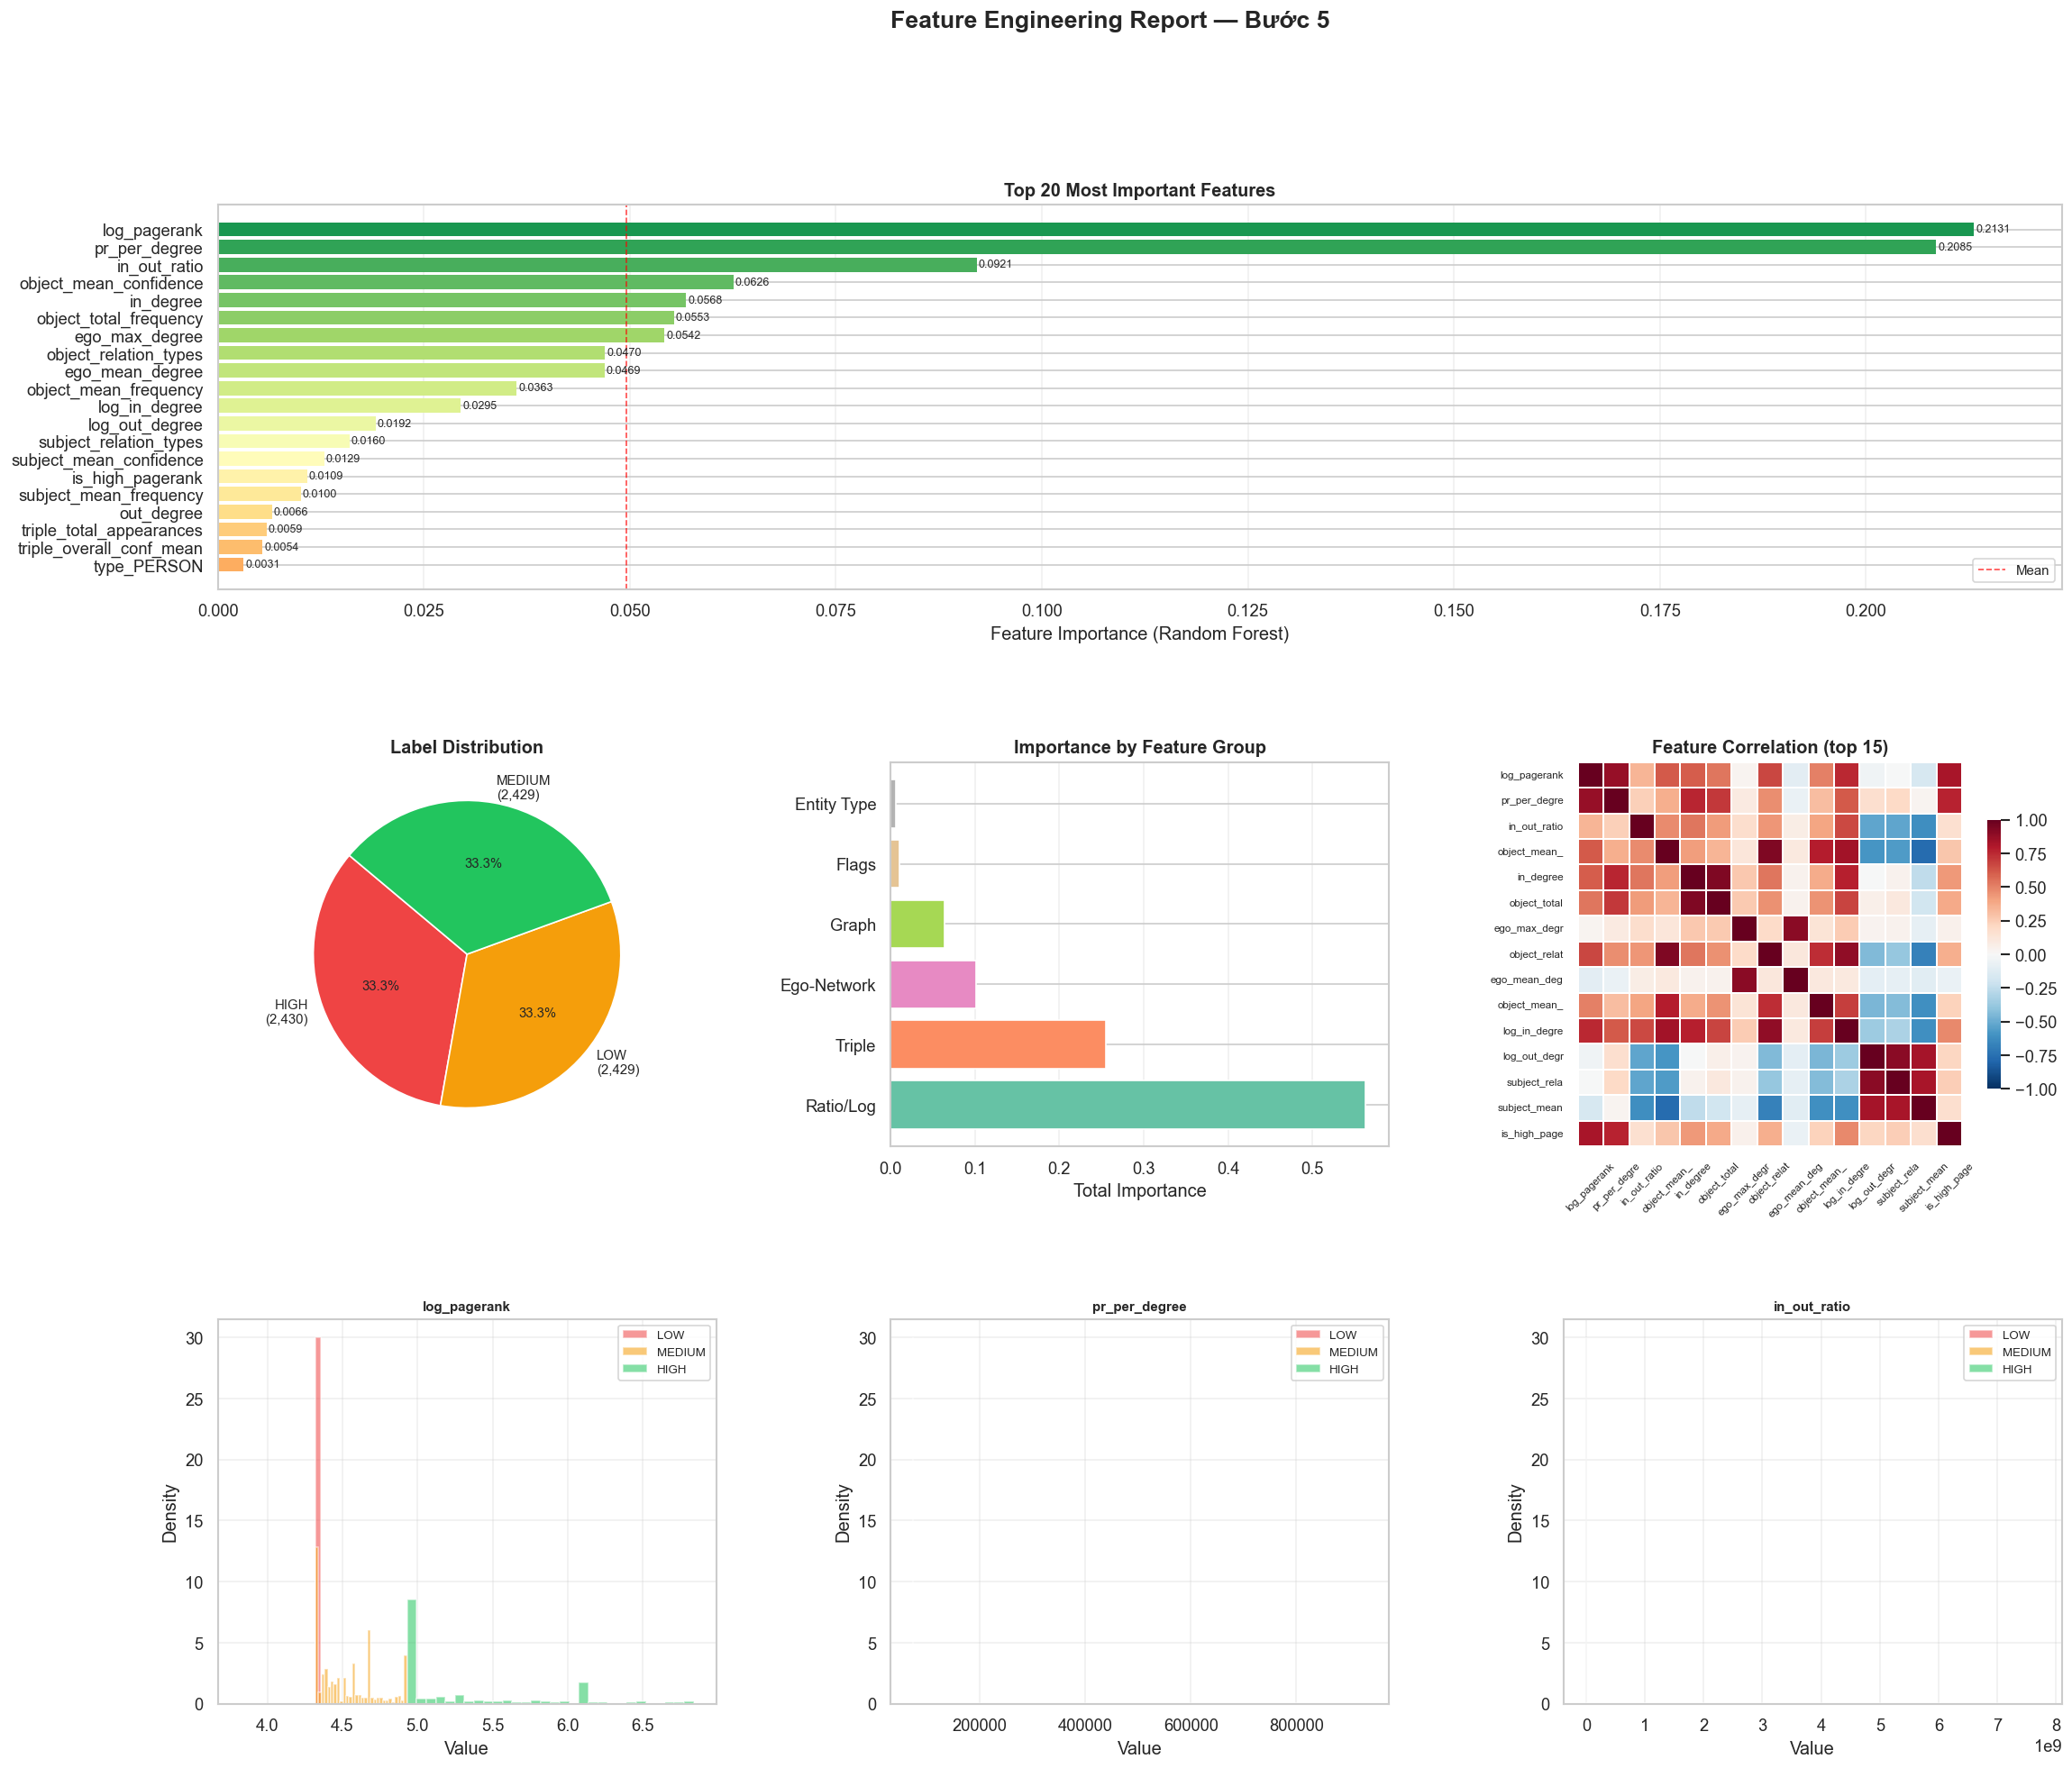

Saved: feature_engineering_output\feature_report.png


In [23]:
fig = plt.figure(figsize=(22, 18))
fig.suptitle('Feature Engineering Report — Bước 5', fontsize=16, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── 1. Feature importance top-20 ─────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
top20 = feat_imp.head(20).iloc[::-1]
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(top20)))
bars = ax1.barh(top20['feature'], top20['importance'], color=colors, edgecolor='none')
ax1.set_xlabel('Feature Importance (Random Forest)')
ax1.set_title('Top 20 Most Important Features', fontweight='bold')
ax1.axvline(top20['importance'].mean(), color='red', ls='--', lw=1, alpha=0.7, label='Mean')
for bar, val in zip(bars, top20['importance']):
    ax1.text(bar.get_width()+0.0002, bar.get_y()+bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=7.5)
ax1.legend(fontsize=9)
ax1.grid(True, axis='x', alpha=0.3)

# ── 2. Label distribution ─────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
label_counts = pd.Series(y).map(dict(enumerate(CFG['label_names']))).value_counts()
colors2 = ['#ef4444','#f59e0b','#22c55e']
wedges, texts, autotexts = ax2.pie(
    label_counts.values,
    labels=[f"{k}\n({v:,})" for k, v in label_counts.items()],
    colors=colors2, autopct='%1.1f%%', startangle=140,
    textprops={'fontsize': 9},
)
ax2.set_title('Label Distribution', fontweight='bold')

# ── 3. Feature group contribution ────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
group_map = {
    'Graph':       [c for c in GRAPH_COLS        if c in TOP_K_FEATURES],
    'Interaction': [c for c in INTERACTION_COLS  if c in TOP_K_FEATURES],
    'Ratio/Log':   [c for c in RATIO_COLS+LOG_COLS+SQRT_FEATURE_COLS if c in TOP_K_FEATURES],
    'Community':   [c for c in COMMUNITY_COLS    if c in TOP_K_FEATURES],
    'Triple':      [c for c in TRIPLE_COLS       if c in TOP_K_FEATURES],
    'Entity Type': [c for c in ENTITY_TYPE_COLS  if c in TOP_K_FEATURES],
    'Ego-Network': [c for c in EGO_COLS          if c in TOP_K_FEATURES],
    'Flags':       [c for c in FLAG_COLS         if c in TOP_K_FEATURES],
}
group_imp = {}
for grp, cols in group_map.items():
    if cols:
        imp_sum = feat_imp[feat_imp['feature'].isin(cols)]['importance'].sum()
        group_imp[grp] = imp_sum

if group_imp:
    sorted_groups = dict(sorted(group_imp.items(), key=lambda x: x[1], reverse=True))
    ax3.barh(list(sorted_groups.keys()), list(sorted_groups.values()),
             color=plt.cm.Set2(np.linspace(0, 1, len(sorted_groups))))
    ax3.set_xlabel('Total Importance')
    ax3.set_title('Importance by Feature Group', fontweight='bold')
    ax3.grid(True, axis='x', alpha=0.3)

# ── 4. Feature correlation heatmap (top 15) ──────────────────
ax4 = fig.add_subplot(gs[1, 2])
top15 = feat_imp.head(15)['feature'].tolist()
corr_top = X_raw[top15].corr()
mask = np.triu(np.ones_like(corr_top, dtype=bool), k=1)
sns.heatmap(
    corr_top, ax=ax4, annot=False,
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.2, square=True,
    xticklabels=[c[:12] for c in top15],
    yticklabels=[c[:12] for c in top15],
    cbar_kws={'shrink':0.7},
)
ax4.set_title('Feature Correlation (top 15)', fontweight='bold')
ax4.tick_params(axis='x', rotation=45, labelsize=7)
ax4.tick_params(axis='y', labelsize=7)

# ── 5. Distribution by label for top-3 features ──────────────
top3_feats = feat_imp.head(3)['feature'].tolist()
label_color = {'LOW':'#ef4444','MEDIUM':'#f59e0b','HIGH':'#22c55e'}

for idx, feat in enumerate(top3_feats):
    ax = fig.add_subplot(gs[2, idx])
    for lbl in CFG['label_names']:
        mask_lbl = df['influence_label'] == lbl
        vals = df.loc[mask_lbl, feat].dropna()
        if len(vals) > 1:
            vals_clipped = vals.clip(
                vals.quantile(0.01), vals.quantile(0.99)
            )
            ax.hist(vals_clipped, bins=30, alpha=0.55,
                    label=lbl, color=label_color[lbl], density=True)
    ax.set_title(f'{feat[:30]}', fontweight='bold', fontsize=9)
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.savefig(OUT / 'feature_report.png', dpi=130, bbox_inches='tight')
plt.show()
print(f"Saved: {OUT / 'feature_report.png'}")

## 11. Correlation Heatmap đầy đủ

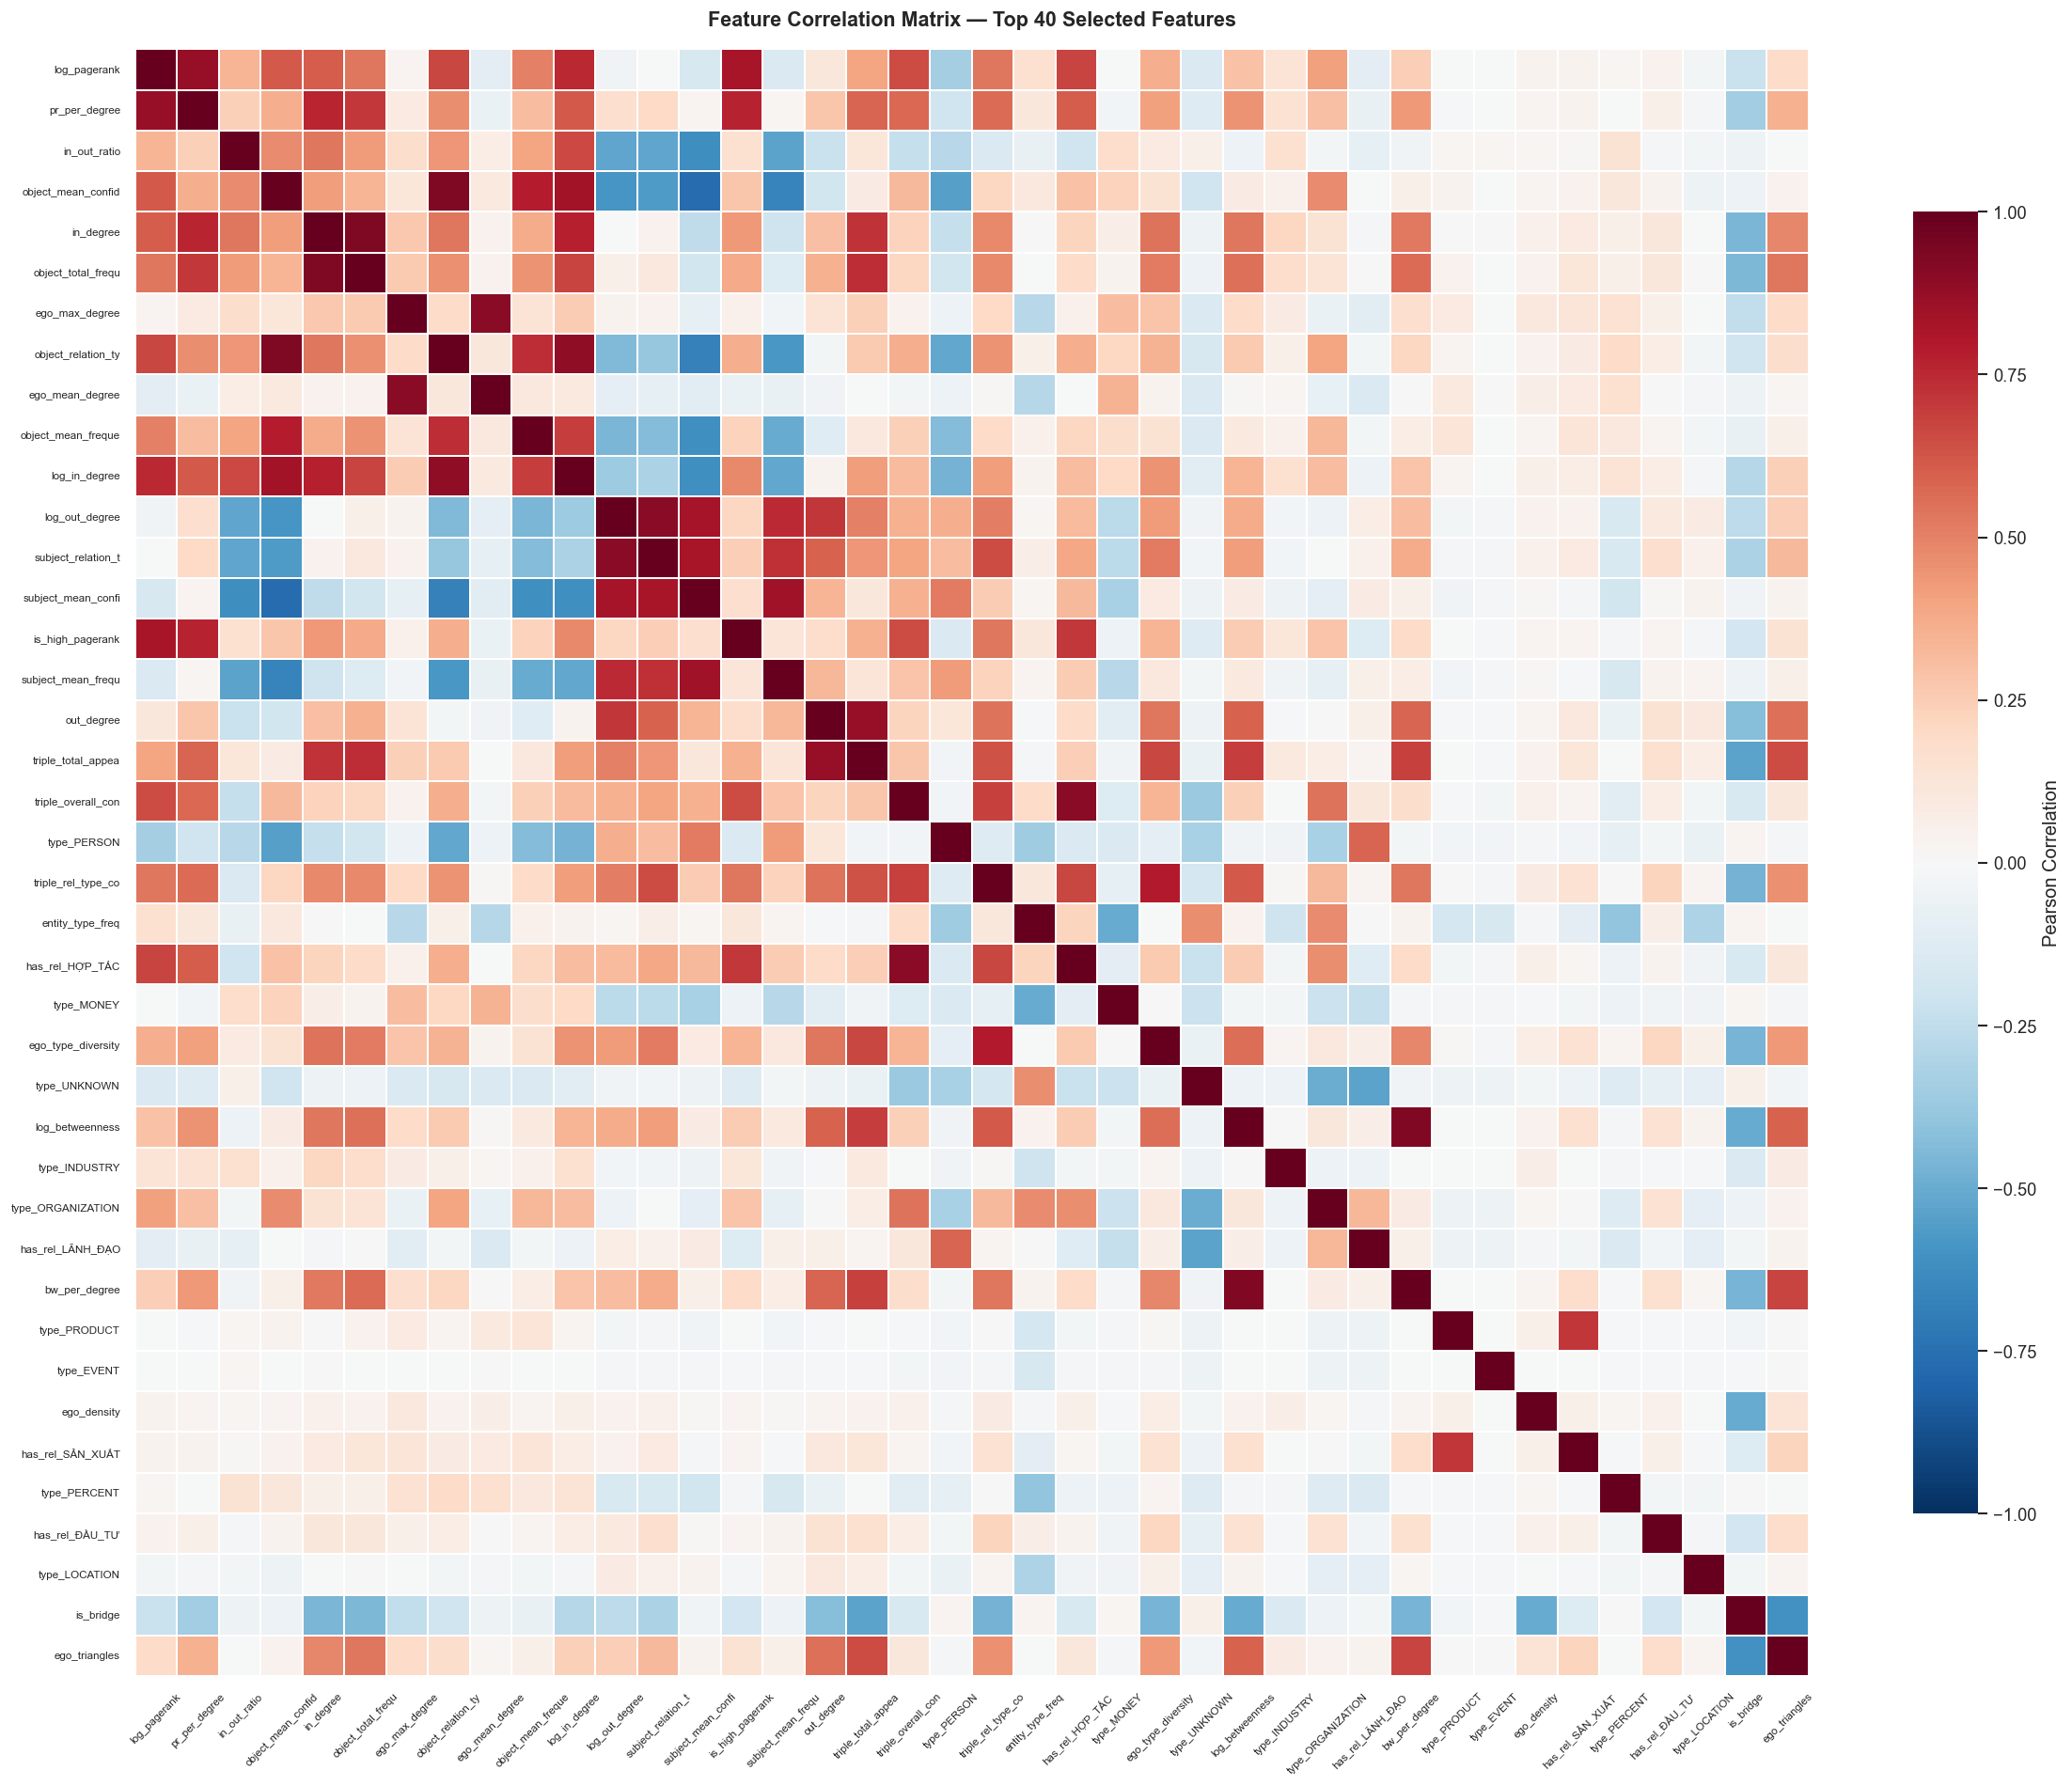

Saved: feature_engineering_output\feature_correlation.png


In [24]:
# Heatmap cho top-K features đã chọn
corr_full = X_raw[TOP_K_FEATURES].corr()

fig, ax = plt.subplots(figsize=(20, 16))
sns.heatmap(
    corr_full, ax=ax,
    annot=len(TOP_K_FEATURES) <= 25,  # chỉ hiện số nếu ≤25 features
    fmt='.2f', annot_kws={'size':6},
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.15,
    xticklabels=[c[:18] for c in TOP_K_FEATURES],
    yticklabels=[c[:18] for c in TOP_K_FEATURES],
    cbar_kws={'shrink':0.8, 'label':'Pearson Correlation'},
)
ax.set_title(f'Feature Correlation Matrix — Top {len(TOP_K_FEATURES)} Selected Features',
             fontsize=13, fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=45, labelsize=7)
ax.tick_params(axis='y', labelsize=7)
plt.tight_layout()
plt.savefig(OUT / 'feature_correlation.png', dpi=130, bbox_inches='tight')
plt.show()
print(f"Saved: {OUT / 'feature_correlation.png'}")

## 12. Final Summary Report

In [25]:
sep = '=' * 60
print(sep)
print('FEATURE ENGINEERING — FINAL SUMMARY')
print(sep)

print(f'\n[Input]')
print(f'  Nodes (total)           : {len(df):,}')
print(f'  Triples                 : {len(df_triples):,}')
print(f'  Graph edges             : {G.number_of_edges():,}')
print(f'  Entity types            : {df["entity_type"].nunique() if "entity_type" in df.columns else "N/A"}')
print(f'  Relation types          : {df_triples["relation"].nunique()}')

print(f'\n[Feature Engineering]')
print(f'  Raw features generated  : {len(ALL_FEATURE_COLS)}')
print(f'  After variance filter   : {len(kept_vt)}')
print(f'  After correlation filter: {len(SELECTED_COLS_AFTER_FILTER)}')
print(f'  Final selected (top-K)  : {len(TOP_K_FEATURES)}')
print(f'  Cumulative importance   : {feat_imp.head(len(TOP_K_FEATURES))["importance"].sum()*100:.1f}%')

print(f'\n[Labels]')
print(f'  Label source            : {label_source}')
for lbl, cnt in label_counts.items():
    print(f'  {lbl:8s}               : {cnt:,} ({cnt/len(y)*100:.1f}%)')

print(f'\n[Data Splits]')
print(f'  Train                   : {len(X_train):,} ({len(X_train)/len(df)*100:.1f}%)')
print(f'  Validation              : {len(X_val):,} ({len(X_val)/len(df)*100:.1f}%)')
print(f'  Test                    : {len(X_test):,} ({len(X_test)/len(df)*100:.1f}%)')
print(f'  Scaler                  : {CFG["scaler_type"].upper()}')

print(f'\n[Top 10 Features by Importance]')
for _, row in feat_imp.head(10).iterrows():
    print(f'  #{int(row["rank"]):2d}  {row["feature"]:40s}  imp={row["importance"]:.5f}')

print(f'\n[Output Files]')
for p in sorted(OUT.iterdir()):
    print(f'  {p.name:40s} {p.stat().st_size/1024:>8.1f} KB')

print(f'\n{sep}')
print('→ X_train/val/test.csv + y_train/val/test.csv sẵn sàng cho Bước 6 (ML)')
print('→ node_features.csv sẵn sàng cho Power BI / phân tích thêm')
print('→ feature_importance.csv để giải thích model')
print(sep)

FEATURE ENGINEERING — FINAL SUMMARY

[Input]
  Nodes (total)           : 7,288
  Triples                 : 6,298
  Graph edges             : 6,226
  Entity types            : 10
  Relation types          : 12

[Feature Engineering]
  Raw features generated  : 99
  After variance filter   : 57
  After correlation filter: 41
  Final selected (top-K)  : 40
  Cumulative importance   : 100.0%

[Labels]
  Label source            : pagerank
  HIGH                   : 2,430 (33.3%)
  LOW                    : 2,429 (33.3%)
  MEDIUM                 : 2,429 (33.3%)

[Data Splits]
  Train                   : 5,100 (70.0%)
  Validation              : 1,094 (15.0%)
  Test                    : 1,094 (15.0%)
  Scaler                  : ROBUST

[Top 10 Features by Importance]
  # 1  log_pagerank                              imp=0.21311
  # 2  pr_per_degree                             imp=0.20851
  # 3  in_out_ratio                              imp=0.09211
  # 4  object_mean_confidence                  

## 13. Tổng kết

### Các feature đã được tạo

| Nhóm | Số features | Mô tả |
|------|------------|-------|
| **Graph structural** | ~16 | Degree, Betweenness, PageRank, HITS, Strength raw metrics |
| **Interaction** | 6 | Tích các metrics quan trọng (PR×Degree, BW×Diversity...) |
| **Ratio** | 7 | In/Out ratio, PR per degree, diversity ratio... |
| **Log/Sqrt transform** | ~14 | Xử lý power-law distribution |
| **Community-relative** | ~17 | Node vs community mean/z-score/percentile |
| **Triple quality** | ~20 | Confidence, frequency, partner diversity từ triples |
| **Entity type** | ~12 | One-hot + frequency encoding |
| **Ego-network** | 9 | Neighbor count, density, clustering, type diversity |
| **Flags** | ~8 | Binary flags: is_hub, is_broker, is_peripheral... |

### Feature selection pipeline

```
~110 raw features
    ↓ Variance threshold (loại near-constant)
    ↓ Correlation filter (loại redundant)
    ↓ Random Forest importance ranking
    ↓
  Top-40 features (cover >95% importance)
```

### Output

| File | Nội dung |
|------|----------|
| `X_train.csv` | Feature matrix train set (scaled) |
| `X_val.csv`   | Feature matrix validation set (scaled) |
| `X_test.csv`  | Feature matrix test set (scaled) |
| `y_train/val/test.csv` | Labels (0=LOW, 1=MEDIUM, 2=HIGH) |
| `feature_names.json`   | Danh sách + nhóm features |
| `scaler_params.json`   | Params để scale data mới |
| `label_encoder.json`   | Label mapping |
| `feature_importance.csv` | Để giải thích model predictions |